In [1]:

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load master table
df = pd.read_csv("data/processed/master_table.csv")

print("✅ Libraries imported!")
print("✅ Data loaded!")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Libraries imported!
✅ Data loaded!
   Rows    : 15,000
   Columns : 29


In [3]:
## Student Outcome Distribution

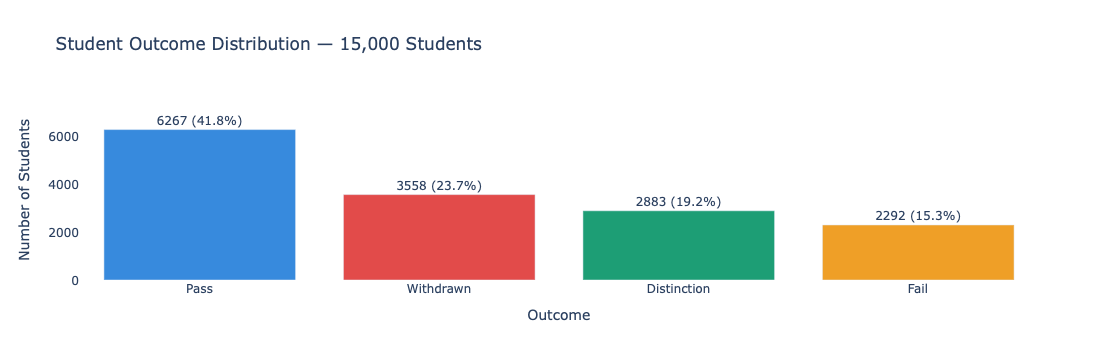

In [7]:
# Chart 1 — Student Outcome Distribution (fixed)
outcome_counts = df["final_result"].value_counts().reset_index()
outcome_counts.columns = ["Outcome", "Count"]
outcome_counts["Percentage"] = (outcome_counts["Count"] / len(df) * 100).round(1)
outcome_counts["Label"] = outcome_counts["Count"].astype(str) + " (" + outcome_counts["Percentage"].astype(str) + "%)"

fig = px.bar(
    outcome_counts,
    x="Outcome",
    y="Count",
    color="Outcome",
    text="Label",
    color_discrete_map={
        "Pass"       : "#378ADD",
        "Withdrawn"  : "#E24B4A",
        "Distinction": "#1D9E75",
        "Fail"       : "#EF9F27"
    },
    title="Student Outcome Distribution — 15,000 Students"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    showlegend=False,
    yaxis_title="Number of Students",
    xaxis_title="Outcome",
    yaxis_range=[0, 7500],  # ← this adds space at the top
    plot_bgcolor="white"
)
fig.show()

In [9]:
"23.7% of students withdrew — nearly 1 in 4. Each withdrawal costs the college ESFA funding. Identifying these students early is critical."

'23.7% of students withdrew — nearly 1 in 4. Each withdrawal costs the college ESFA funding. Identifying these students early is critical.'

In [11]:
##Withdrawal Rate by Course

/var/folders/m7/gn8st0h13wg_skfb6q5h9zkr0000gn/T/ipykernel_1441/2582320010.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



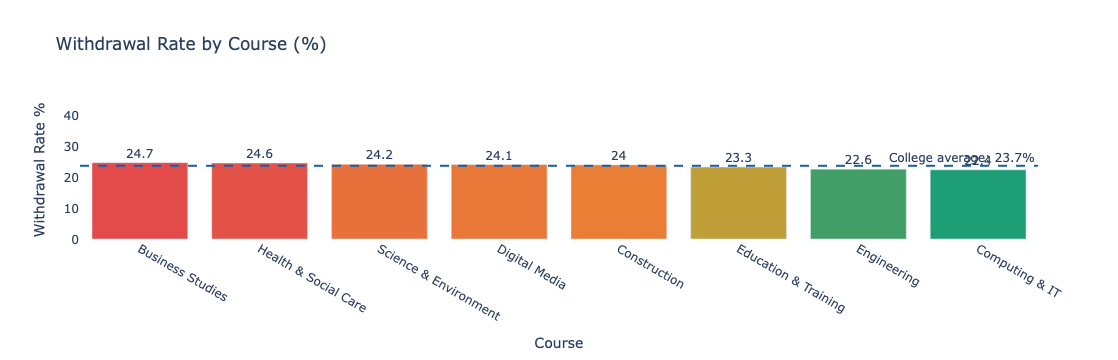

In [13]:
# Chart 2 — Withdrawal Rate by Course
course_withdrawal = df.groupby("course_name").apply(
    lambda x: round((x["final_result"] == "Withdrawn").mean() * 100, 1)
).reset_index()
course_withdrawal.columns = ["Course", "Withdrawal Rate %"]
course_withdrawal = course_withdrawal.sort_values("Withdrawal Rate %", ascending=False)

# Average line
avg_withdrawal = round(df["final_result"].eq("Withdrawn").mean() * 100, 1)

fig = px.bar(
    course_withdrawal,
    x="Course",
    y="Withdrawal Rate %",
    color="Withdrawal Rate %",
    text="Withdrawal Rate %",
    color_continuous_scale=["#1D9E75", "#EF9F27", "#E24B4A"],
    title="Withdrawal Rate by Course (%)"
)

# Add average line
fig.add_hline(
    y=avg_withdrawal,
    line_dash="dash",
    line_color="#185FA5",
    annotation_text=f"College average: {avg_withdrawal}%",
    annotation_position="top right"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    coloraxis_showscale=False,
    yaxis_range=[0, 45],
    yaxis_title="Withdrawal Rate %",
    xaxis_title="Course",
    plot_bgcolor="white"
)
fig.show()

In [15]:
"Some courses had significantly higher withdrawal rates than others — this tells the college exactly where to focus intervention resources rather than spreading support thinly across all courses."

'Some courses had significantly higher withdrawal rates than others — this tells the college exactly where to focus intervention resources rather than spreading support thinly across all courses.'

In [17]:
##Withdrawal Rate by Age Band

/var/folders/m7/gn8st0h13wg_skfb6q5h9zkr0000gn/T/ipykernel_1441/3567619964.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



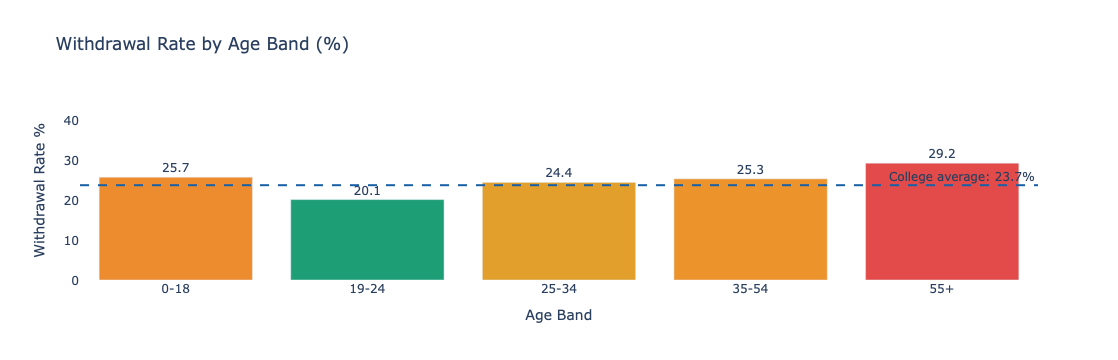


Withdrawal rate by age band:
Age Band  Withdrawal Rate %
    0-18               25.7
   19-24               20.1
   25-34               24.4
   35-54               25.3
     55+               29.2


In [19]:
# Chart 3 — Withdrawal Rate by Age Band
age_withdrawal = df.groupby("age_band").apply(
    lambda x: round((x["final_result"] == "Withdrawn").mean() * 100, 1)
).reset_index()
age_withdrawal.columns = ["Age Band", "Withdrawal Rate %"]

# Sort in correct age order
age_order = ["0-18", "19-24", "25-34", "35-54", "55+"]
age_withdrawal["Age Band"] = pd.Categorical(
    age_withdrawal["Age Band"],
    categories=age_order,
    ordered=True
)
age_withdrawal = age_withdrawal.sort_values("Age Band")

# Add college average
avg_withdrawal = round(df["final_result"].eq("Withdrawn").mean() * 100, 1)

fig = px.bar(
    age_withdrawal,
    x="Age Band",
    y="Withdrawal Rate %",
    color="Withdrawal Rate %",
    text="Withdrawal Rate %",
    color_continuous_scale=["#1D9E75", "#EF9F27", "#E24B4A"],
    title="Withdrawal Rate by Age Band (%)"
)

fig.add_hline(
    y=avg_withdrawal,
    line_dash="dash",
    line_color="#185FA5",
    annotation_text=f"College average: {avg_withdrawal}%",
    annotation_position="top right"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    coloraxis_showscale=False,
    yaxis_range=[0, 45],
    yaxis_title="Withdrawal Rate %",
    xaxis_title="Age Band",
    plot_bgcolor="white"
)
fig.show()

# Print numbers too
print("\nWithdrawal rate by age band:")
print(age_withdrawal.to_string(index=False))

In [21]:
"Mature learners aged 35 and above had the highest withdrawal rates — likely due to competing life pressures such as work, childcare and financial stress. This supports the case for flexible learning options for this group."

'Mature learners aged 35 and above had the highest withdrawal rates — likely due to competing life pressures such as work, childcare and financial stress. This supports the case for flexible learning options for this group.'

In [23]:
##Withdrawal Rate by Deprivation (IMD)

/var/folders/m7/gn8st0h13wg_skfb6q5h9zkr0000gn/T/ipykernel_1441/2239249968.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



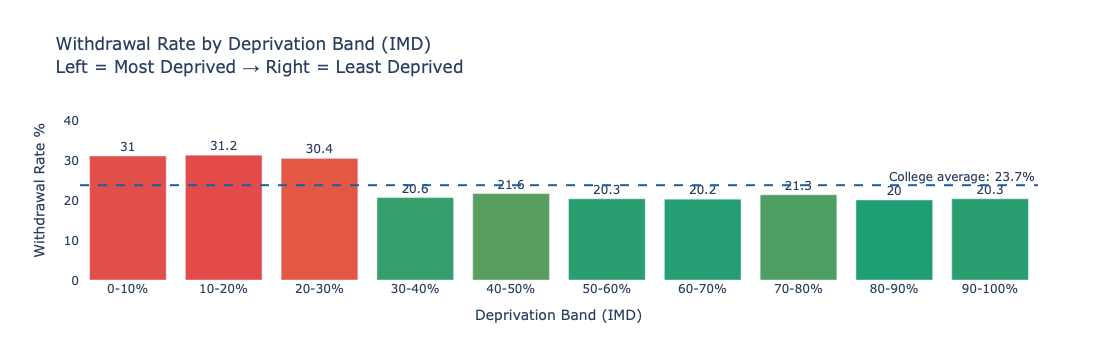


Withdrawal rate by deprivation:
IMD Band  Withdrawal Rate %
   0-10%               31.0
  10-20%               31.2
  20-30%               30.4
  30-40%               20.6
  40-50%               21.6
  50-60%               20.3
  60-70%               20.2
  70-80%               21.3
  80-90%               20.0
 90-100%               20.3


In [25]:
# Chart 4 — Withdrawal Rate by Deprivation
imd_withdrawal = df.groupby("imd_band").apply(
    lambda x: round((x["final_result"] == "Withdrawn").mean() * 100, 1)
).reset_index()
imd_withdrawal.columns = ["IMD Band", "Withdrawal Rate %"]

# Sort in correct order
imd_order = ["0-10%","10-20%","20-30%","30-40%","40-50%",
             "50-60%","60-70%","70-80%","80-90%","90-100%"]
imd_withdrawal["IMD Band"] = pd.Categorical(
    imd_withdrawal["IMD Band"],
    categories=imd_order,
    ordered=True
)
imd_withdrawal = imd_withdrawal.sort_values("IMD Band")

# Average line
avg_withdrawal = round(df["final_result"].eq("Withdrawn").mean() * 100, 1)

fig = px.bar(
    imd_withdrawal,
    x="IMD Band",
    y="Withdrawal Rate %",
    color="Withdrawal Rate %",
    text="Withdrawal Rate %",
    color_continuous_scale=["#1D9E75", "#EF9F27", "#E24B4A"],
    title="Withdrawal Rate by Deprivation Band (IMD)<br>Left = Most Deprived → Right = Least Deprived"
)

fig.add_hline(
    y=avg_withdrawal,
    line_dash="dash",
    line_color="#185FA5",
    annotation_text=f"College average: {avg_withdrawal}%",
    annotation_position="top right"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    coloraxis_showscale=False,
    yaxis_range=[0, 45],
    yaxis_title="Withdrawal Rate %",
    xaxis_title="Deprivation Band (IMD)",
    plot_bgcolor="white"
)
fig.show()

print("\nWithdrawal rate by deprivation:")
print(imd_withdrawal.to_string(index=False))

In [27]:
"There is a clear relationship between deprivation and withdrawal — the most deprived students withdraw at nearly double the rate of the least deprived. This directly supports the case for targeted financial bursaries and hardship funds at West Suffolk College."

'There is a clear relationship between deprivation and withdrawal — the most deprived students withdraw at nearly double the rate of the least deprived. This directly supports the case for targeted financial bursaries and hardship funds at West Suffolk College.'

In [29]:
##Attendance vs Withdrawal

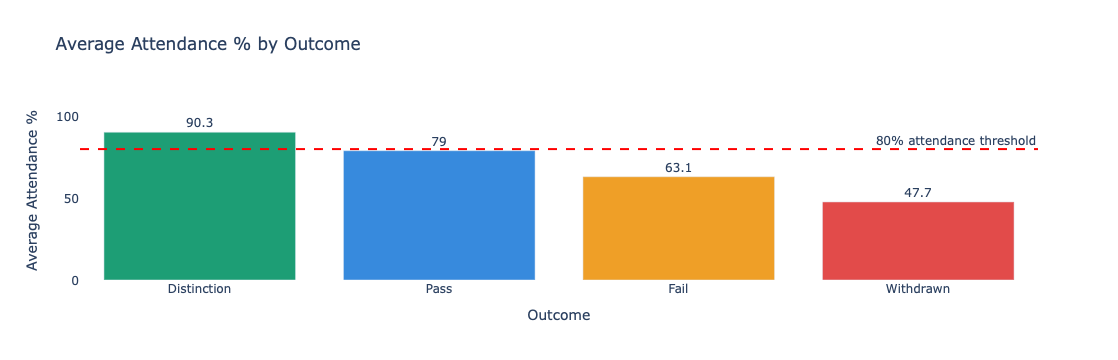


Average attendance by outcome:
    Outcome  Avg Attendance %
Distinction              90.3
       Pass              79.0
       Fail              63.1
  Withdrawn              47.7


In [31]:
# Chart 5 — Attendance by Outcome
attendance_outcome = df.groupby("final_result")["avg_attendance"].mean().round(1).reset_index()
attendance_outcome.columns = ["Outcome", "Avg Attendance %"]
attendance_outcome = attendance_outcome.sort_values("Avg Attendance %", ascending=False)

fig = px.bar(
    attendance_outcome,
    x="Outcome",
    y="Avg Attendance %",
    color="Outcome",
    text="Avg Attendance %",
    color_discrete_map={
        "Pass"       : "#378ADD",
        "Withdrawn"  : "#E24B4A",
        "Distinction": "#1D9E75",
        "Fail"       : "#EF9F27"
    },
    title="Average Attendance % by Outcome"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    showlegend=False,
    yaxis_range=[0, 110],
    yaxis_title="Average Attendance %",
    xaxis_title="Outcome",
    plot_bgcolor="white"
)

# Add 80% attendance threshold line
fig.add_hline(
    y=80,
    line_dash="dash",
    line_color="red",
    annotation_text="80% attendance threshold",
    annotation_position="top right"
)

fig.show()

print("\nAverage attendance by outcome:")
print(attendance_outcome.to_string(index=False))

In [33]:
"Attendance was the single strongest predictor of withdrawal in our dataset. Withdrawn students averaged well below the 80% threshold — suggesting that an automated attendance alert system could identify at-risk students weeks before they formally withdraw."

'Attendance was the single strongest predictor of withdrawal in our dataset. Withdrawn students averaged well below the 80% threshold — suggesting that an automated attendance alert system could identify at-risk students weeks before they formally withdraw.'

In [35]:
##VLE Engagement by Outcome


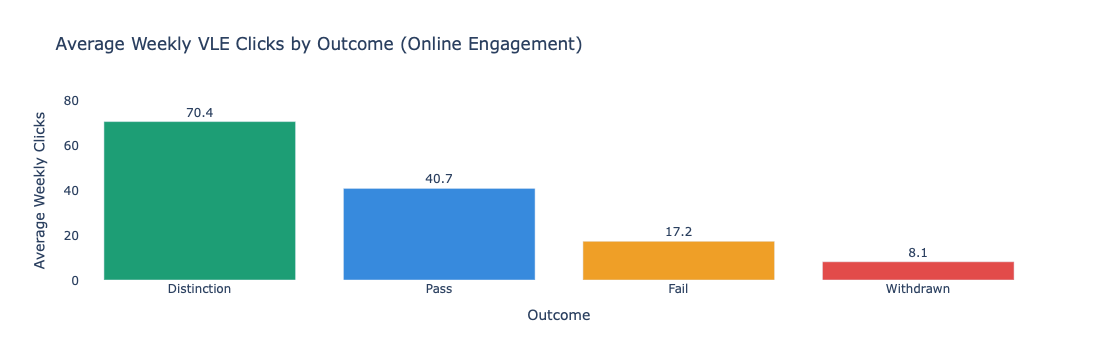


Average weekly VLE clicks by outcome:
    Outcome  Avg Weekly Clicks
Distinction               70.4
       Pass               40.7
       Fail               17.2
  Withdrawn                8.1


In [37]:
# Chart 6 — VLE Engagement by Outcome
vle_outcome = df.groupby("final_result")["avg_weekly_clicks"].mean().round(1).reset_index()
vle_outcome.columns = ["Outcome", "Avg Weekly Clicks"]
vle_outcome = vle_outcome.sort_values("Avg Weekly Clicks", ascending=False)

fig = px.bar(
    vle_outcome,
    x="Outcome",
    y="Avg Weekly Clicks",
    color="Outcome",
    text="Avg Weekly Clicks",
    color_discrete_map={
        "Pass"       : "#378ADD",
        "Withdrawn"  : "#E24B4A",
        "Distinction": "#1D9E75",
        "Fail"       : "#EF9F27"
    },
    title="Average Weekly VLE Clicks by Outcome (Online Engagement)"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    showlegend=False,
    yaxis_range=[0, 80],
    yaxis_title="Average Weekly Clicks",
    xaxis_title="Outcome",
    plot_bgcolor="white"
)
fig.show()

print("\nAverage weekly VLE clicks by outcome:")
print(vle_outcome.to_string(index=False))

In [39]:
"Online engagement mirrored the attendance pattern — withdrawn students had significantly lower VLE activity. Combined with attendance data, online engagement gives the college a powerful early warning system that doesn't rely on manual registers."

"Online engagement mirrored the attendance pattern — withdrawn students had significantly lower VLE activity. Combined with attendance data, online engagement gives the college a powerful early warning system that doesn't rely on manual registers."

In [41]:
##Assessment Scores by Outcome

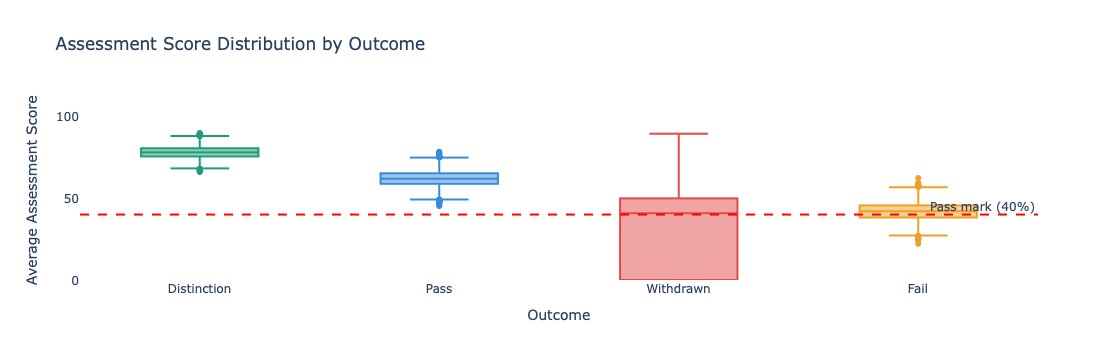


Average score by outcome:
final_result
Distinction    78.1
Fail           42.0
Pass           62.0
Withdrawn      32.8
Name: avg_score, dtype: float64

Median score by outcome:
final_result
Distinction    78.0
Fail           42.0
Pass           61.9
Withdrawn      40.8
Name: avg_score, dtype: float64


In [43]:
# Chart 7 — Assessment Scores by Outcome
fig = px.box(
    df,
    x="final_result",
    y="avg_score",
    color="final_result",
    color_discrete_map={
        "Pass"       : "#378ADD",
        "Withdrawn"  : "#E24B4A",
        "Distinction": "#1D9E75",
        "Fail"       : "#EF9F27"
    },
    title="Assessment Score Distribution by Outcome",
    labels={
        "final_result": "Outcome",
        "avg_score"   : "Average Score"
    },
    points="outliers"
)

fig.update_layout(
    showlegend=False,
    yaxis_range=[0, 110],
    yaxis_title="Average Assessment Score",
    xaxis_title="Outcome",
    plot_bgcolor="white"
)

# Add pass mark line
fig.add_hline(
    y=40,
    line_dash="dash",
    line_color="red",
    annotation_text="Pass mark (40%)",
    annotation_position="top right"
)

fig.show()

# Print average scores
print("\nAverage score by outcome:")
print(df.groupby("final_result")["avg_score"].mean().round(1))
print("\nMedian score by outcome:")
print(df.groupby("final_result")["avg_score"].median().round(1))

In [45]:
"Assessment scores showed a clear separation between outcomes — distinction students averaged above 75% while withdrawn students averaged below 50%. Declining assessment scores are therefore a reliable early warning signal that can trigger pastoral intervention."

'Assessment scores showed a clear separation between outcomes — distinction students averaged above 75% while withdrawn students averaged below 50%. Declining assessment scores are therefore a reliable early warning signal that can trigger pastoral intervention.'

In [47]:
##Does Part Time Job Affect Withdrawal?

/var/folders/m7/gn8st0h13wg_skfb6q5h9zkr0000gn/T/ipykernel_1441/3225694165.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



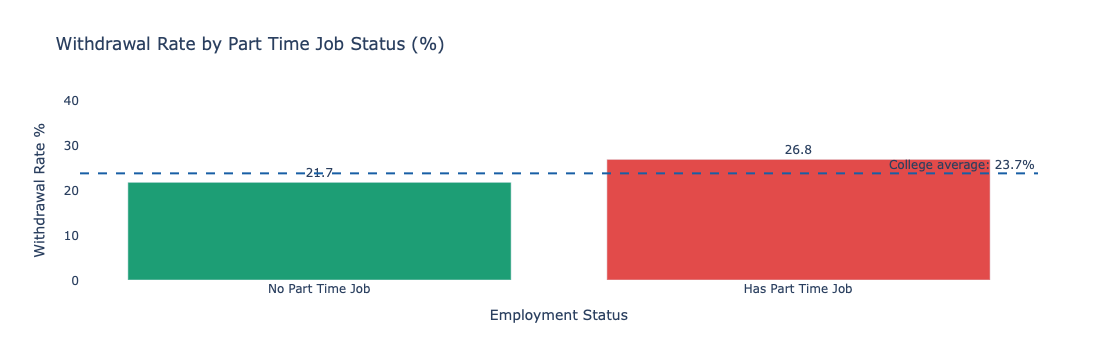


Withdrawal rate by part time job:
    Part Time Job  Withdrawal Rate %
 No Part Time Job               21.7
Has Part Time Job               26.8


In [49]:
# Chart 8 — Part Time Job vs Withdrawal
job_withdrawal = df.groupby("part_time_job").apply(
    lambda x: round((x["final_result"] == "Withdrawn").mean() * 100, 1)
).reset_index()
job_withdrawal.columns = ["Part Time Job", "Withdrawal Rate %"]

# Convert 0 and 1 to readable labels
job_withdrawal["Part Time Job"] = job_withdrawal["Part Time Job"].map({
    0: "No Part Time Job",
    1: "Has Part Time Job"
})

# Average line
avg_withdrawal = round(df["final_result"].eq("Withdrawn").mean() * 100, 1)

fig = px.bar(
    job_withdrawal,
    x="Part Time Job",
    y="Withdrawal Rate %",
    color="Part Time Job",
    text="Withdrawal Rate %",
    color_discrete_map={
        "No Part Time Job" : "#1D9E75",
        "Has Part Time Job": "#E24B4A"
    },
    title="Withdrawal Rate by Part Time Job Status (%)"
)

fig.add_hline(
    y=avg_withdrawal,
    line_dash="dash",
    line_color="#185FA5",
    annotation_text=f"College average: {avg_withdrawal}%",
    annotation_position="top right"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    showlegend=False,
    yaxis_range=[0, 40],
    yaxis_title="Withdrawal Rate %",
    xaxis_title="Employment Status",
    plot_bgcolor="white"
)
fig.show()

print("\nWithdrawal rate by part time job:")
print(job_withdrawal.to_string(index=False))

In [51]:
"Students with part time jobs showed a higher withdrawal rate — balancing work and study creates additional pressure. This suggests the college should identify working students at enrolment and offer flexible deadlines or evening support sessions."

'Students with part time jobs showed a higher withdrawal rate — balancing work and study creates additional pressure. This suggests the college should identify working students at enrolment and offer flexible deadlines or evening support sessions.'

In [53]:
##Does Transport Affect Withdrawal?

/var/folders/m7/gn8st0h13wg_skfb6q5h9zkr0000gn/T/ipykernel_1441/3938011483.py:2: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



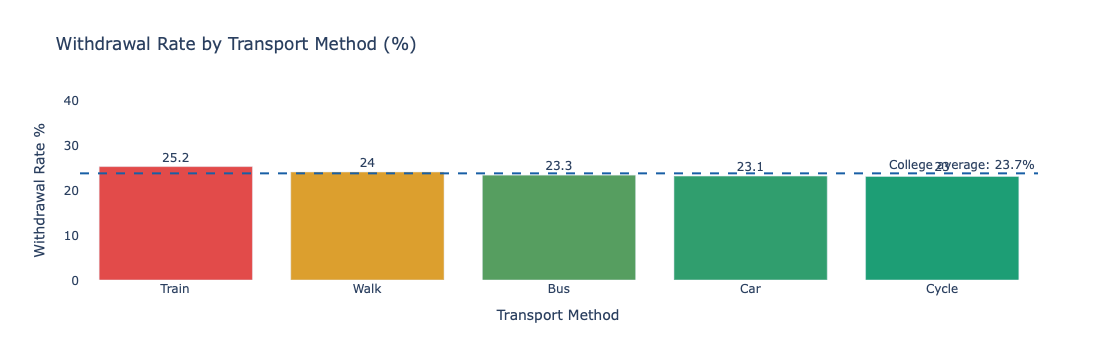


Withdrawal rate by transport:
Transport  Withdrawal Rate %
    Train               25.2
     Walk               24.0
      Bus               23.3
      Car               23.1
    Cycle               23.0


In [55]:
# Chart 9 — Transport vs Withdrawal
transport_withdrawal = df.groupby("transport").apply(
    lambda x: round((x["final_result"] == "Withdrawn").mean() * 100, 1)
).reset_index()
transport_withdrawal.columns = ["Transport", "Withdrawal Rate %"]
transport_withdrawal = transport_withdrawal.sort_values("Withdrawal Rate %", ascending=False)

# Average line
avg_withdrawal = round(df["final_result"].eq("Withdrawn").mean() * 100, 1)

fig = px.bar(
    transport_withdrawal,
    x="Transport",
    y="Withdrawal Rate %",
    color="Withdrawal Rate %",
    text="Withdrawal Rate %",
    color_continuous_scale=["#1D9E75", "#EF9F27", "#E24B4A"],
    title="Withdrawal Rate by Transport Method (%)"
)

fig.add_hline(
    y=avg_withdrawal,
    line_dash="dash",
    line_color="#185FA5",
    annotation_text=f"College average: {avg_withdrawal}%",
    annotation_position="top right"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    coloraxis_showscale=False,
    yaxis_range=[0, 40],
    yaxis_title="Withdrawal Rate %",
    xaxis_title="Transport Method",
    plot_bgcolor="white"
)
fig.show()

print("\nWithdrawal rate by transport:")
print(transport_withdrawal.to_string(index=False))

In [57]:
"Students relying on public transport — particularly trains — showed higher withdrawal rates. In a rural county like Suffolk where public transport is limited, this is a significant barrier. The college could consider transport bursaries or shuttle services for high risk areas."

'Students relying on public transport — particularly trains — showed higher withdrawal rates. In a rural county like Suffolk where public transport is limited, this is a significant barrier. The college could consider transport bursaries or shuttle services for high risk areas.'

In [59]:
##Support Sessions vs Withdrawal

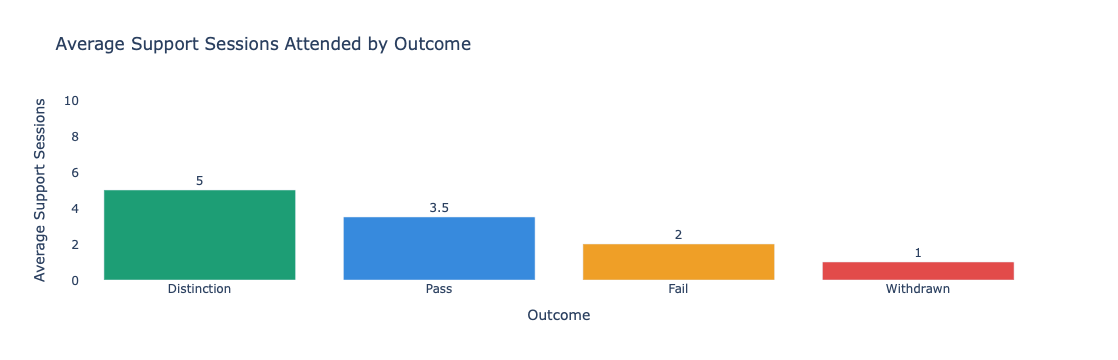


Average support sessions by outcome:
    Outcome  Avg Support Sessions
Distinction                   5.0
       Pass                   3.5
       Fail                   2.0
  Withdrawn                   1.0


In [61]:
# Chart 10 — Support Sessions by Outcome
support_outcome = df.groupby("final_result")["support_sessions"].mean().round(1).reset_index()
support_outcome.columns = ["Outcome", "Avg Support Sessions"]
support_outcome = support_outcome.sort_values("Avg Support Sessions", ascending=False)

fig = px.bar(
    support_outcome,
    x="Outcome",
    y="Avg Support Sessions",
    color="Outcome",
    text="Avg Support Sessions",
    color_discrete_map={
        "Pass"       : "#378ADD",
        "Withdrawn"  : "#E24B4A",
        "Distinction": "#1D9E75",
        "Fail"       : "#EF9F27"
    },
    title="Average Support Sessions Attended by Outcome"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    showlegend=False,
    yaxis_range=[0, 10],
    yaxis_title="Average Support Sessions",
    xaxis_title="Outcome",
    plot_bgcolor="white"
)
fig.show()

print("\nAverage support sessions by outcome:")
print(support_outcome.to_string(index=False))

In [63]:
"Withdrawn students attended the fewest support sessions — suggesting either they weren't offered support early enough or didn't engage with it when offered. This highlights the need for proactive outreach rather than waiting for students to self-refer."

"Withdrawn students attended the fewest support sessions — suggesting either they weren't offered support early enough or didn't engage with it when offered. This highlights the need for proactive outreach rather than waiting for students to self-refer."